In [3]:
from sklearn.linear_model import LinearRegression
import pandas as pd


In [5]:
news = pd.read_csv("NewspaperData.csv")

In [6]:
news

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093
5,Chicago Tribune,733.775,1133.249
6,Cincinnati Enquirer,198.832,348.744
7,Denver Post,252.624,417.779
8,Des Moines Register,206.204,344.522
9,Hartford Courant,231.177,323.084


In [8]:
news['Newspaper'].nunique()

34

In [9]:
news.shape

(34, 3)

In [10]:
del news['Newspaper']
news

,daily,sunday
0,391.952,488.506
1,516.981,798.298
2,355.628,235.084
3,238.555,299.451
4,537.780,559.093
5,733.775,1133.249
6,198.832,348.744
7,252.624,417.779
8,206.204,344.522
9,231.177,323.084


In [11]:
news.describe

<bound method NDFrame.describe of        daily    sunday
0    391.952   488.506
1    516.981   798.298
2    355.628   235.084
3    238.555   299.451
4    537.780   559.093
5    733.775  1133.249
6    198.832   348.744
7    252.624   417.779
8    206.204   344.522
9    231.177   323.084
10   449.755   620.752
11   288.571   423.305
12   185.736   202.614
13  1164.388  1531.527
14   444.581   553.479
15   412.871   685.975
16   272.280   324.241
17   781.796   983.240
18  1209.225  1762.015
19   825.512   960.308
20   223.748   284.611
21   354.843   407.760
22   515.523   982.663
23   220.465   557.000
24   337.672   440.923
25   197.120   268.060
26   133.239   262.048
27   374.009   432.502
28   273.844   338.355
29   570.364   704.322
30   391.286   585.681
31   201.860   267.781
32   321.626   408.343
33   838.902  1165.567>

In [12]:
news.info

<bound method DataFrame.info of        daily    sunday
0    391.952   488.506
1    516.981   798.298
2    355.628   235.084
3    238.555   299.451
4    537.780   559.093
5    733.775  1133.249
6    198.832   348.744
7    252.624   417.779
8    206.204   344.522
9    231.177   323.084
10   449.755   620.752
11   288.571   423.305
12   185.736   202.614
13  1164.388  1531.527
14   444.581   553.479
15   412.871   685.975
16   272.280   324.241
17   781.796   983.240
18  1209.225  1762.015
19   825.512   960.308
20   223.748   284.611
21   354.843   407.760
22   515.523   982.663
23   220.465   557.000
24   337.672   440.923
25   197.120   268.060
26   133.239   262.048
27   374.009   432.502
28   273.844   338.355
29   570.364   704.322
30   391.286   585.681
31   201.860   267.781
32   321.626   408.343
33   838.902  1165.567>

In [15]:
news.dtypes #checkinmg data types

daily     float64
sunday    float64
dtype: object

In [17]:
news.isna().sum() #checking null vales

daily     0
sunday    0
dtype: int64

In [19]:
news[news.duplicated()].sum() #checkig duplicates

daily     0.0
sunday    0.0
dtype: float64

In [20]:
# using scatter plot to define relationship bw 2 continuoes values

import matplotlib.pyplot as plt

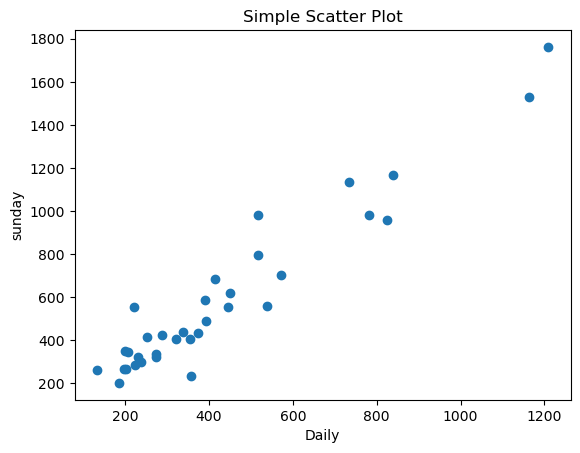

In [22]:
plt.scatter(news['daily'],news['sunday'])
plt.xlabel('Daily')
plt.ylabel('sunday')
plt.title('Simple Scatter Plot')
plt.show()

In [25]:
x = news[['daily']]
x

,daily
0,391.952
1,516.981
2,355.628
3,238.555
4,537.780
5,733.775
6,198.832
7,252.624
8,206.204
9,231.177


In [26]:
y = news[['sunday']]
y

,sunday
0,488.506
1,798.298
2,235.084
3,299.451
4,559.093
5,1133.249
6,348.744
7,417.779
8,344.522
9,323.084


In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
slr = LinearRegression() #model building
slr.fit(x,y) #model training
y_pred = slr.predict(x)
y_pred

array([[ 538.93950861],
       [ 706.44270505],
       [ 490.27570976],
       [ 333.43128393],
       [ 734.3074323 ],
       [ 996.88482623],
       [ 280.21379461],
       [ 352.27973085],
       [ 290.0901718 ],
       [ 323.54686845],
       [ 616.37904075],
       [ 400.43845725],
       [ 262.66889014],
       [1573.78341718],
       [ 609.4473566 ],
       [ 566.96500163],
       [ 378.61316413],
       [1061.21926861],
       [1633.85220777],
       [1119.78623895],
       [ 313.59412751],
       [ 489.22403367],
       [ 704.48940094],
       [ 309.19584396],
       [ 466.21979157],
       [ 277.92020294],
       [ 192.33788451],
       [ 514.90100672],
       [ 380.70847801],
       [ 777.96069796],
       [ 538.04725858],
       [ 284.2704509 ],
       [ 444.72272856],
       [1137.72501956]])

In [29]:
slr.coef_

array([[1.33971476]])

In [30]:
slr.intercept_

array([13.83562991])

In [31]:
# 1.34x + 13.84
(1.33971476 * 391.95) + 13.83562991

538.9368300919999

In [32]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error #Evaluation

In [33]:
r2_score(y,y_pred) #Evaluating

0.9180596895873295

In [34]:
error = y-y_pred

In [35]:
lr = (error*error).sum()
lr

sunday    383135.530456
dtype: float64

In [36]:
avg = (y.mean()-y).sum()
avg

sunday    2.501110e-12
dtype: float64

In [37]:
mean_squared_error(y,y_pred) #MSE

11268.692072241498

In [38]:
mean_absolute_error(y,y_pred) #MAE

80.1327444999346

In [39]:
delivery = pd.read_csv("delivery_time.csv")

In [40]:
delivery

,Delivery_Time,Sorting_Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10
5,15.35,6
6,19.00,7
7,9.50,3
8,17.90,10
9,18.75,9


In [41]:
delivery.isna().sum()

Delivery_Time    0
Sorting_Time     0
dtype: int64

In [42]:
delivery[delivery.duplicated()].sum()

Delivery_Time    0.0
Sorting_Time     0.0
dtype: float64

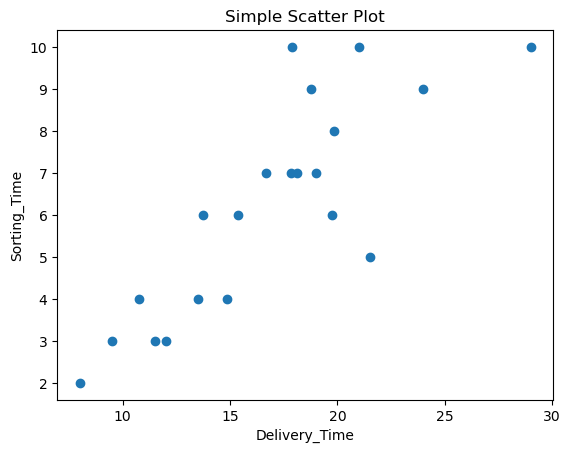

In [43]:
plt.scatter(delivery['Delivery_Time'],delivery['Sorting_Time'])
plt.xlabel('Delivery_Time')
plt.ylabel('Sorting_Time')
plt.title('Simple Scatter Plot')
plt.show()

In [45]:
x = delivery[['Delivery_Time']]

In [46]:
y = delivery[['Sorting_Time']]

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
slr = LinearRegression()
slr.fit(x,y)
y_pred = slr.predict(x)
y_pred

array([[ 7.93194282],
       [ 4.82886561],
       [ 7.41476329],
       [ 9.17317371],
       [11.24189185],
       [ 5.59429132],
       [ 7.10445557],
       [ 3.1738911 ],
       [ 6.64933758],
       [ 7.00101966],
       [ 7.44786278],
       [ 3.69107064],
       [ 6.14457035],
       [ 4.00137836],
       [ 4.22066248],
       [ 5.39983182],
       [ 4.93230152],
       [ 6.73622374],
       [ 2.55327566],
       [ 6.62037552],
       [ 8.13881464]])

In [49]:
from sklearn.metrics import r2_score

In [50]:
r2_score(y,y_pred)

0.682271474841723

In [52]:
salary = pd.read_csv('Salary_Data.csv')

In [53]:
salary

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [54]:
salary.info

<bound method DataFrame.info of     YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0>

In [55]:
salary[salary.duplicated()].sum()

YearsExperience    0.0
Salary             0.0
dtype: float64

In [56]:
salary.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [57]:
salary.shape

(30, 2)

In [58]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

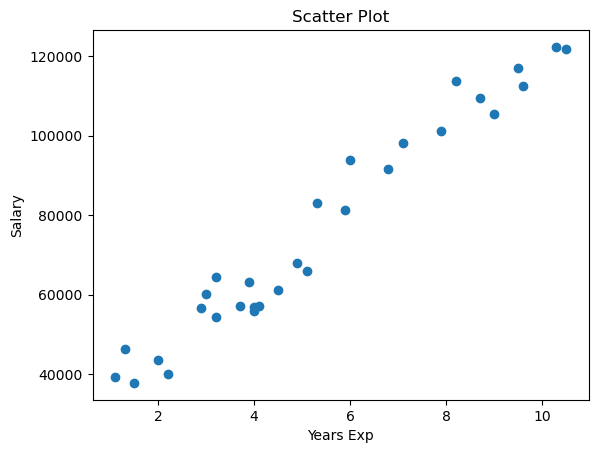

In [62]:
plt.scatter(salary['YearsExperience'],salary['Salary'])
plt.xlabel('Years Exp')
plt.ylabel('Salary')
plt.title("Scatter Plot")
plt.show

In [65]:
x = salary[['YearsExperience']]

In [66]:
y = salary[['Salary']]

In [64]:
from sklearn.linear_model import LinearRegression

In [67]:
slr = LinearRegression()
slr.fit(x,y)
y_pred = slr.predict(x)
y_pred

array([[ 36187.15875227],
       [ 38077.15121656],
       [ 39967.14368085],
       [ 44692.12484158],
       [ 46582.11730587],
       [ 53197.09093089],
       [ 54142.08716303],
       [ 56032.07962732],
       [ 56032.07962732],
       [ 60757.06078805],
       [ 62647.05325234],
       [ 63592.04948449],
       [ 63592.04948449],
       [ 64537.04571663],
       [ 68317.03064522],
       [ 72097.0155738 ],
       [ 73987.00803809],
       [ 75877.00050238],
       [ 81546.97789525],
       [ 82491.9741274 ],
       [ 90051.94398456],
       [ 92886.932681  ],
       [100446.90253816],
       [103281.8912346 ],
       [108006.87239533],
       [110841.86109176],
       [115566.84225249],
       [116511.83848464],
       [123126.81210966],
       [125016.80457395]])

In [68]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error,mean_absolute_percentage_error

In [69]:
r2_score(y,y_pred)

0.9569566641435086

In [70]:
mean_absolute_error(y,y_pred)

4644.2012894435375

In [71]:
mean_squared_error(y,y_pred)

31270951.722280968